# Narssaq ca. 1184 Ma paleomagnetic pole

## Geologic Context

The Gardar Igneous Province is a major magmatic event in Laurentia exposed in Greenland; it  is composed of a suite of peralkaline igneous complexes and basic dike swarms.  In the eastern part of the province, there are NE-SW trending dikes and alkaline plutons that are interpeted to be a renewed and final stage of magmatism.  

A system of giant gabbro dikes  on the island of Tugtutôq continues north eastwards onto the mainland as the Narssaq gabbro. The Narssaq gabbro developed as a horizontal sill-like body along an unconformity between the granitic basement rocks and the sedimentary-volcanic Eriksfjord supracrustal suite.  Based on the dipping of zones of feldspar lamination, the original center of the gabbro complex was interpreted to be in the north, but is not preserved.

The Narssaq gabbro is intruded by several small ultramafic bodies, which were suggested to be connected at depth. 

^^paraphrased from Piper et al. (1977)

## Paleomagnetic And Rock Magnetic Data
Piper (1977) drilled cores at 7 sites within the gabbro, with four of those in the ultramafic bodies. Samples were demagnetized in steps of 5 or 10  mT up to peak fields between 40 and 100 mT; demagnetization was halted when increased in magnetization (a.k.a. a GRM) occurred. Components were determined using  Fisher mean over the stable range (typically 15-50 mT).

Thermomagnetic curves were performed on at least one sample from each site highlighting complexity in the magnetic characters; however, the main carrier is titanomagntite with Curie temperatures ranging from 425 - 555°C.  Additional petrographic analyses were performed measuring approximately 60 grains in polished sections from each site.  Intergrown magnetite and ilmenite were identified in each sample with varying levels of oxidation interpreted to be during to cooling; hematite was identified in 4 samples as isolated grains or as fine exsoution lamellae in host ilmenite grains.  Trace amounts of sulfides were identified in a four sites, wiht one containing 5.2% (and unstable remanence).

Three sites were excluded from the mean direction of the giant gabbro dike system; two of the sites grouped with other directions in the study that had much shallower easterly directions compared to the other samples.  This direction is similar to a NE trending swarm of basic and intermediate minor dikes in the same region so was suggested to be an overprint, etc. The other excluded site also had an anomalous direciton but didn't group with these.

No structural corrections were performed on these samples/sites.

- B = 4 sites, N = 22 samples; mean direction DEC/INC = 285.3°/46.8°; K = 97.0.

## Age Constraints

- Current bracket: lomagage 1179.0 Ma, himagage 1189.0 Ma.
- Compilation method note: Considered the older giant dike, there is a 1184±5 associated with Hviddal giant dyke. Dates are from the compilation of Upton et al., 2013 citing mostly unpublished Heaman dates. 

## References

- Paleomagnetic source: Piper, J.D.A. (1977). Palaeomagnetism of the giant dykes of Tugtutoq and Narssaq Gabbro, Gardar Igneous Province, South Greenland. BGS Denmark, 26, 85-94.
- Geochronology / age-constraint note (compilation): - Geochronology / age-constraint note (compilation): Upton, B. G. J. (2013). Tectono-magmatic evolution of the younger Gardar southern rift, South Greenland. Geological Survey of Denmark and Greenland Bulletin, 29, 1–124. https://doi.org/10.34194/geusb.v29.4692

## Calculations

In [3]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import pmagpy.pmag as pmag
import pmagpy.ipmag as ipmag
import matplotlib.pyplot as plt

%matplotlib inline
import matplotlib_inline

import pole_tools as pt

## Read in sites

In [10]:
sites_df = pd.read_csv('../data/1184_Narssaq/sites.txt', sep='\t',header=1)

In [11]:
sites_df.head()

,site,location,result_type,result_quality,method_codes,citations,geologic_classes,geologic_types,lithologies,lat,lon,age,age_sigma,age_low,age_high,age_unit,dir_tilt_correction,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon,vgp_dp,vgp_dm,description
0,26,Narssaq Gabbro,i,b,DE-FM,Piper1977Narssaq,Igneous,Pluton,Gabbro,60.92,-46.06,1184,NaN,1179,1189,Ma,0,50.4,19.7,15.0,17.9,6,27,75,NaN,NaN,Site-mean directions from Piper (1977).
1,27,Narssaq Gabbro,i,g,DE-FM,Piper1977Narssaq,Igneous,Pluton,Gabbro,60.92,-46.06,1184,NaN,1179,1189,Ma,0,280.8,47.4,176.0,5.1,6,30,230,NaN,NaN,Site-mean directions from Piper (1977).
2,28,Narssaq Gabbro,i,b,DE-FM,Piper1977Narssaq,Igneous,Pluton,Gabbro,60.92,-46.06,1184,NaN,1179,1189,Ma,0,61.8,-26.5,22.0,14.7,6,75,1,NaN,NaN,Site-mean directions from Piper (1977).
3,29,Narssaq Gabbro,i,g,DE-FM,Piper1977Narssaq,Igneous,Pluton,Gabbro,60.92,-46.06,1184,NaN,1179,1189,Ma,0,285.1,39.5,186.0,4.9,6,27,222,NaN,NaN,Site-mean directions from Piper (1977).
4,30,Narssaq Gabbro,i,g,DE-FM,Piper1977Narssaq,Igneous,Pluton,Gabbro,60.92,-46.06,1184,NaN,1179,1189,Ma,0,298.0,46.8,157.0,6.1,5,38,214,NaN,NaN,Site-mean directions from Piper (1977).


## Site location map

Note that there is no latitude and longitude information provided for these samples.  There is a hand-drawn map and it needs to be georeferenced.  In the meantime, place holder latitude and longitude was used near the center of the samples sites based on visual examination.

In [12]:
study_lat = 60.92	
study_lon = -46.06

In [13]:
pt.plot_site_map(sites_df)

## Site directions (as measured at site)

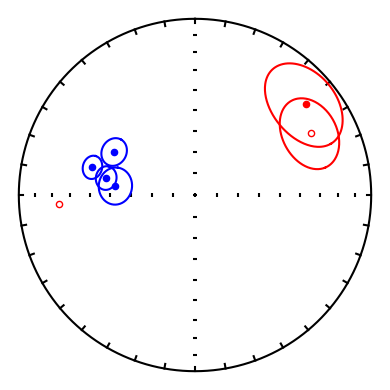

In [14]:
plt.figure(figsize = (4,4))
ipmag.plot_net()

for row, site in sites_df.iterrows():
    if  site['result_quality'] == 'g':
        col = 'b'
    elif site['result_quality'] == 'b':
        col = 'r'
    ipmag.plot_di_mean(dec=site['dir_dec'],
                       inc=site['dir_inc'],
                       a95=site['dir_alpha95'],
                       color=col)

## Mean pole from VGPs

Plon: 225.7  Plat: 31.8
Number of directions in mean (n): 4
Angular radius of 95% confidence (A_95): 10.6
Precision parameter (k) estimate: 76.4


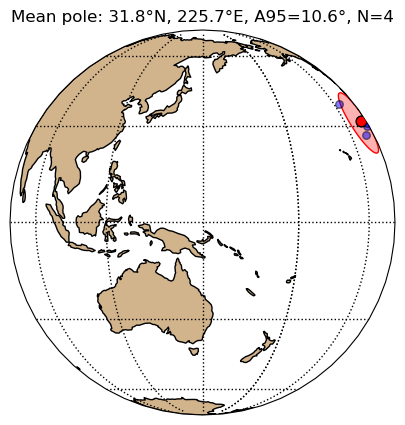

In [15]:
sites_subset = sites_df[sites_df['result_quality'] == 'g']

vgp_block, pole_mean = pt.compute_mean_pole(sites_subset)
ipmag.print_pole_mean(pole_mean)
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, figsize=(5,5))

## Pole in the context of the Laurentia APWP

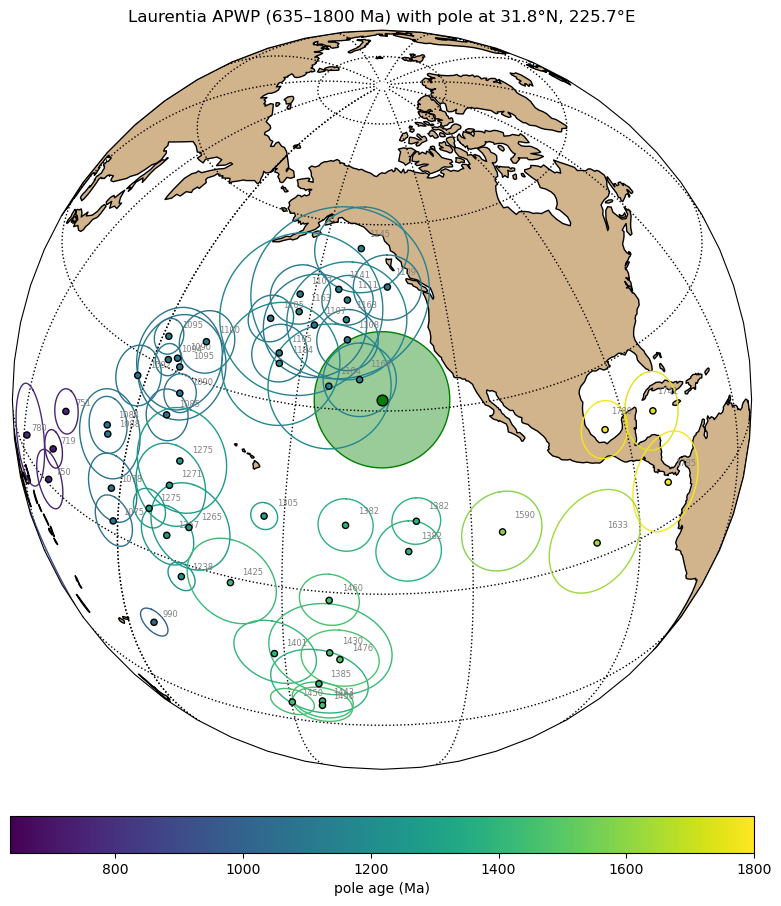

In [16]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=pole_mean['dec'], central_latitude=pole_mean['inc'])
plt.show()

## R2: Deenen test

In [ ]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()